Phần I

Câu 1:

In [23]:
import pandas as pd

def load_data():
    df = pd.read_csv("titanic_disaster.csv")
    return df

df = load_data()
print(df.head(10))


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

Câu 2:

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


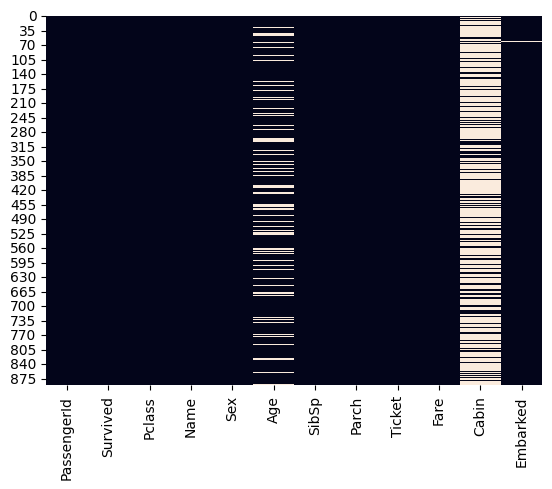

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

print(df.isna().sum())

sns.heatmap(df.isna(), cbar=False)
plt.show()


Câu 3:

In [25]:
df[['firstName','secondName']] = df['Name'].str.split(',', n=1, expand=True)
df.drop('Name', axis=1, inplace=True)
print(df[['firstName','secondName']].head())

   firstName                                   secondName
0     Braund                              Mr. Owen Harris
1    Cumings   Mrs. John Bradley (Florence Briggs Thayer)
2  Heikkinen                                  Miss. Laina
3   Futrelle           Mrs. Jacques Heath (Lily May Peel)
4      Allen                            Mr. William Henry


Câu 4:

In [26]:
df['Sex'] = df['Sex'].replace({'male':'M','female':'F'})
print(df['Sex'].unique())

['M' 'F']


Câu 5:

In [27]:
import numpy as np

df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.mean()))

print(df['Age'].isna().sum())

0


Câu 6:

In [28]:
def age_group(age):
    if age <= 12: return 'Kid'
    elif age <= 18: return 'Teen'
    elif age <= 60: return 'Adult'
    else: return 'Older'

df['Agegroup'] = df['Age'].apply(age_group)
print(df[['Age','Agegroup']].head())

    Age Agegroup
0  22.0    Adult
1  38.0    Adult
2  26.0    Adult
3  35.0    Adult
4  35.0    Adult


Câu 7:

In [29]:
df['namePrefix'] = df['secondName'].str.extract(r'(Mr|Mrs|Miss|Master)')
print(df['namePrefix'].value_counts())

namePrefix
Mr        645
Miss      182
Master     40
Name: count, dtype: int64


Câu 8:

In [30]:
df['familySize'] = 1 + df['SibSp'] + df['Parch']
print(df[['SibSp','Parch','familySize']].head())

   SibSp  Parch  familySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1


Câu 9:

In [31]:
df['Alone'] = (df['familySize'] == 1).astype(int)
print(df[['familySize','Alone']].head())

   familySize  Alone
0           2      0
1           2      0
2           1      1
3           2      0
4           1      1


Câu 10:

In [32]:
df['typeCabin'] = df['Cabin'].str[0]
df['typeCabin'] = df['typeCabin'].fillna('Unknown')
print(df['typeCabin'].value_counts())

typeCabin
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64


Câu 11:

In [33]:
df.drop_duplicates(inplace=True)

Phần II

Câu 12:

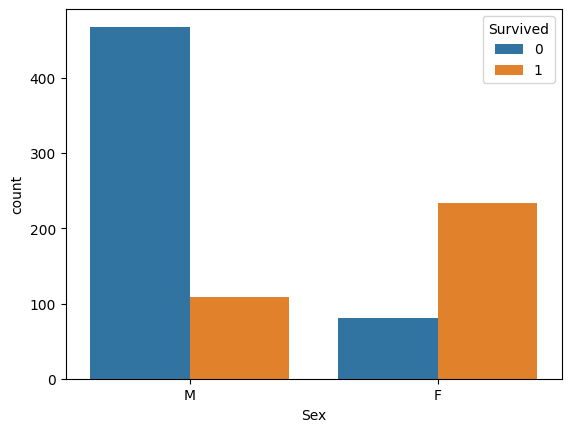

In [34]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()

Câu 13:

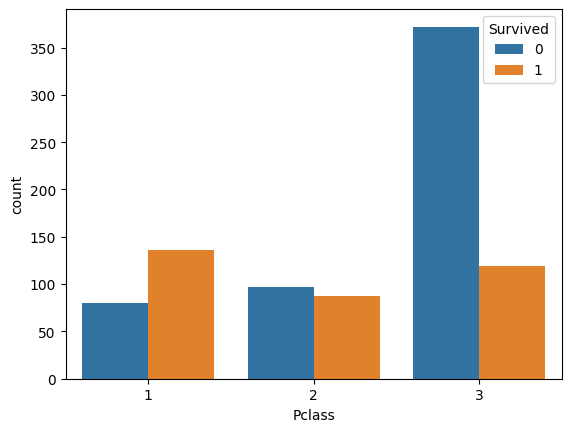

In [35]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()

Câu 14:

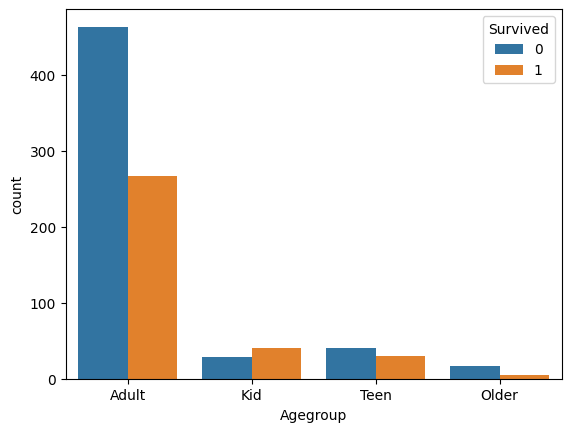

In [17]:
sns.countplot(x='Agegroup', hue='Survived', data=df)
plt.show()

Câu 15:

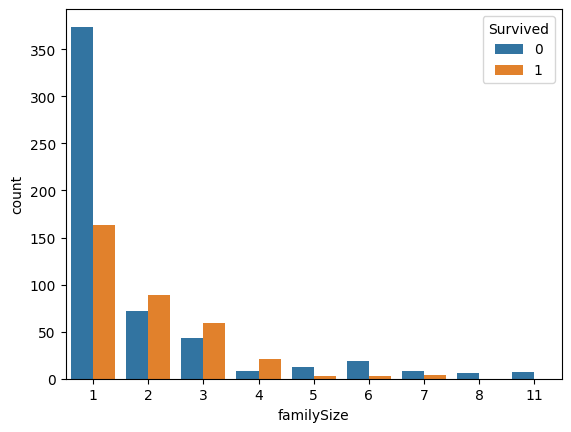

In [18]:
sns.countplot(x='familySize', hue='Survived', data=df)
plt.show()

Câu 16:

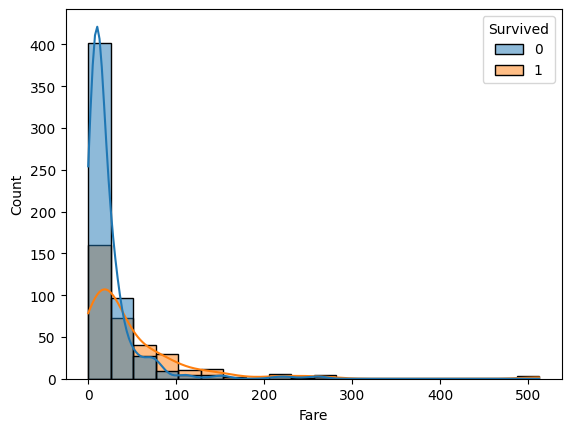

In [22]:
sns.histplot(df, x='Fare', hue='Survived', bins=20, kde=True)
plt.show()

Câu 17:

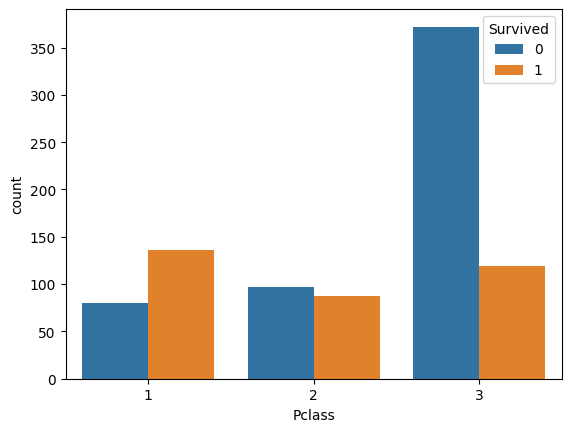

In [21]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()